Identify the key entities in the financial article and generate a summary for each. by extractive method (summary)

In [19]:
import spacy
import matplotlib.pyplot as plt
import numpy as np
import nltk
from collections import defaultdict
from nltk.tokenize import sent_tokenize
from collections import defaultdict, Counter
from transformers import pipeline
from collections import Counter
from nltk.corpus import reuters
from nltk.tokenize import sent_tokenize
from lexrank import LexRank
from lexrank.mappings.stopwords import STOPWORDS
from bert_score import score
from rouge_score import rouge_scorer

nltk.download('punkt')
nltk.download('reuters')
#nltk.download('punkt_tab')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\Justine\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package reuters to
[nltk_data]     C:\Users\Justine\AppData\Roaming\nltk_data...
[nltk_data]   Package reuters is already up-to-date!


True

In [20]:
file = "Text_Input.txt"

file_path = rf"D:\Project\Trading\Stage_L3\Extractive Method\{file}"

with open(file_path, "r", encoding="utf-8") as f:
    text = f.read()

In [21]:
#Compute METRICS ROUGE and BERTScore
def ComputeMetrics(summary,benchmark_summary,metric,flag):
    #summary generated
    print("--- Summary generated ---")
    if flag :
        summary = " ".join(summary)  
    print(summary)

    #benchmark summary
    print("--- benchmark summary ---")
    benchmark_summary = " ".join(benchmark_summary)  
    print(benchmark_summary)

    match metric:
        case 'bertscore':
            #Compute BERTScore
            P, R, F1 = score([summary], [benchmark_summary], lang="en", verbose=True)

            print("\n--- Scores BERTscore (compared to benchmark summary) ---")
            print(f"Precision: {P.mean():.4f}")
            print(f"Recall: {R.mean():.4f}")
            print(f"F1: {F1.mean():.4f}")

        case 'rouge':
            #Compute ROUGE
            scorer = rouge_scorer.RougeScorer(['rouge1', 'rouge2', 'rougeL'], use_stemmer=True)
            scores = scorer.score(benchmark_summary, summary)

            print("\n--- Scores ROUGE (compared to benchmark summary) ---")
            for key, value in scores.items():
                print(f"{key}: Precision={value.precision:.3f} Recall={value.recall:.3f} ")

- Use Bert for NER 

In [22]:
#Load BERT-NER model
ner = pipeline("ner",model="dslim/bert-base-NER",aggregation_strategy="simple") 

#Extract ORG entities with positions
results = ner(text)
entities_positions = [(entity["word"], entity["start"]) for entity in results if entity["entity_group"] == "ORG"]

freq = Counter([ent for ent, pos in entities_positions])

print("Entities and positions:", entities_positions)
print("Frequencies:", freq)


Some weights of the model checkpoint at dslim/bert-base-NER were not used when initializing BertForTokenClassification: ['bert.pooler.dense.bias', 'bert.pooler.dense.weight']
- This IS expected if you are initializing BertForTokenClassification from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing BertForTokenClassification from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).
Device set to use cpu


Entities and positions: [('Alphabet', 0), ('GO', 12), ('##GL', 15), ('O', 18), ('Google', 36), ('OpenAI', 269), ('Google', 277), ('I / O', 376), ('Google', 625), ('OpenAI', 793), ('Google Search', 864), ('Google', 1054), ('Alphabet', 1265), ('Google', 1429), ('Google', 1613), ('Google', 1829), ('Marine', 1989), ('Gemini', 2118)]
Frequencies: Counter({'Google': 7, 'Alphabet': 2, 'OpenAI': 2, 'GO': 1, '##GL': 1, 'O': 1, 'I / O': 1, 'Google Search': 1, 'Marine': 1, 'Gemini': 1})


Add a score for each entity (a combination of frequency and position in the text).

In [24]:

text_length = len(text)
#Weight for the position of entitie in the article
def position_score(start_char):
    if start_char < 0.2 * text_length:
        return 1.5  
    elif start_char > 0.8 * text_length:
        return 1.2  
    else:
        return 1.0

pos_scores = defaultdict(float)
for entities, scores in entities_positions:
    pos_scores[entities] += position_score(scores)

#Combine frequency and position scores
importance_scores = {}
for entities in freq:
    importance_scores[entities] = freq[entities] * pos_scores[entities]

sorted_entities = sorted(importance_scores.items(), key=lambda x: x[1], reverse=True)

Retrieve the most importants entities in this financial article

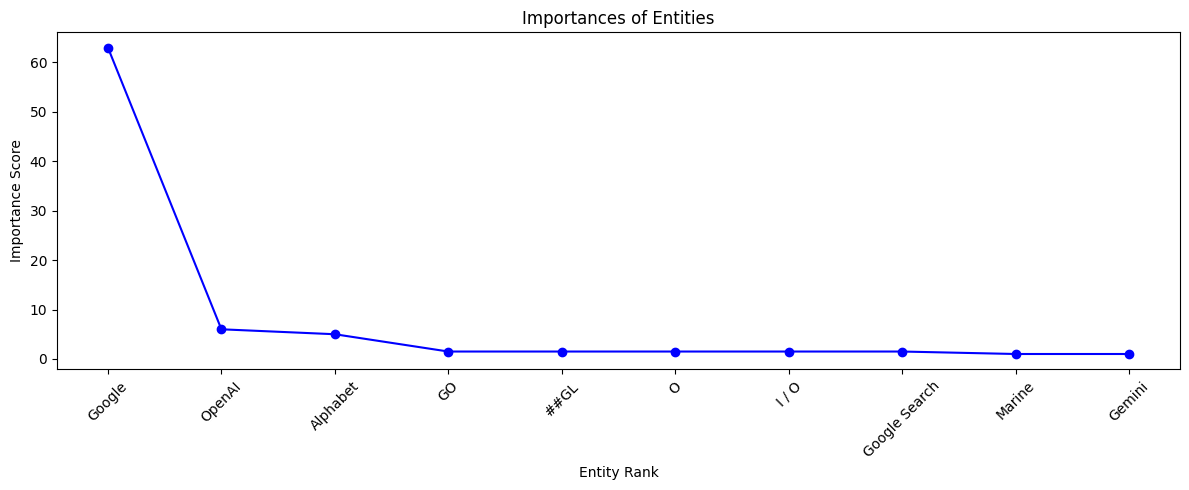

Suggested number of important entities (before score stabilization): 1
Important entities:
Google: 63.00


In [34]:
entities, scores = zip(*sorted_entities)

#Graph with the score for each entitie
plt.figure(figsize=(12, 5))
plt.plot(range(1, len(scores)+1), scores, marker='o', color='blue')
plt.title("Importances of Entities")
plt.xlabel("Entity Rank")
plt.ylabel("Importance Score")
plt.grid(False)
plt.xticks(range(1, len(scores)+1), [f"{ent}" for ent in entities], rotation=45)
plt.tight_layout()
plt.show()

#Compute to find number of entities to keep based on the coude method, used for the K-means
relative_threshold = 0.2 * (max(scores) - min(scores))
cutoff_index = len(scores)
for i in range(len(scores) - 1):
    delta = scores[i] - scores[i+1]
    if delta < relative_threshold:
        cutoff_index = i 
        break

print(f"Suggested number of important entities (before score stabilization): {cutoff_index}")
print("Important entities:")
for i in range(cutoff_index):
    print(f"{entities[i]}: {scores[i]:.2f}")


top_entities = sorted_entities[:cutoff_index]

Assign each sentence to the most important entity

In [ ]:

sentences = sent_tokenize(text)

#Build a mapping of sentence
sentence_entity_map = defaultdict(list)

for sent in sentences:
    for entity, _ in top_entities:
        if entity in sent:
            sentence_entity_map[sent].append(entity)


entity_sentence_map = defaultdict(list)
importance_lookup = dict(top_entities)

for sent, ents in sentence_entity_map.items():
    if len(ents) == 1:
        entity_sentence_map[ents[0]].append(sent)
    else:
        best_entity = max(ents, key=lambda e: importance_lookup.get(e, 0))
        entity_sentence_map[best_entity].append(sent)


Create a text for each entity

In [ ]:
for entity, _ in top_entities:
    unique_sentences = entity_sentence_map.get(entity, [])
    if not unique_sentences:
        print(f"No exclusive content for entity '{entity}'. Skipping.\n")
        continue
    entity_text = " ".join(unique_sentences)

Use LexRank to create a summary.

In [31]:
documents = []
for fileid in reuters.fileids()[:1000]: 
    raw_text = reuters.raw(fileid)
    sentences = sent_tokenize(raw_text)
    documents.append(sentences)

lxr = LexRank(documents, stopwords=STOPWORDS['en'])
sentences = sent_tokenize(entity_text)
summary = lxr.get_summary(sentences, summary_size=3, threshold=0.2)


print("\nSummary:")
for line in summary:
    print("-", line)




Summary:
- Google already offers other subscription options, including a $19.99-per-month service with access to some AI capabilities unavailable for most free users and cheaper plans with additional cloud storage.
- Google also announced an “AI Ultra Plan,” which for $249.99 monthly provides users with higher limits on AI and early access to experimental tools like Project Mariner, an internet browser extension that can automate keystrokes and mouse clicks, and Deep Think, a version of its top-shelf Gemini model that is more capable of reasoning through complicated tasks.
- In a number of demos, Google drew on capabilities developed in a testing ground it has called Project Astra to show off what its latest AI could do.


In [32]:
benchmark_summary = ["Google brings 'AI Mode' to all U.S. users in bid to maintain search dominance. Analysts predict Google's search market share may drop below 50% in five years. Google touts glasses, new AI features as step towards 'universal' assistants"]
ComputeMetrics(summary,benchmark_summary,"bertscore",True)

--- Summary generated ---
Google already offers other subscription options, including a $19.99-per-month service with access to some AI capabilities unavailable for most free users and cheaper plans with additional cloud storage. Google also announced an “AI Ultra Plan,” which for $249.99 monthly provides users with higher limits on AI and early access to experimental tools like Project Mariner, an internet browser extension that can automate keystrokes and mouse clicks, and Deep Think, a version of its top-shelf Gemini model that is more capable of reasoning through complicated tasks. In a number of demos, Google drew on capabilities developed in a testing ground it has called Project Astra to show off what its latest AI could do.
--- benchmark summary ---
Google brings 'AI Mode' to all U.S. users in bid to maintain search dominance. Analysts predict Google's search market share may drop below 50% in five years. Google touts glasses, new AI features as step towards 'universal' assista

Some weights of RobertaModel were not initialized from the model checkpoint at roberta-large and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


calculating scores...
computing bert embedding.


100%|██████████| 1/1 [00:19<00:00, 19.21s/it]


computing greedy matching.


100%|██████████| 1/1 [00:00<00:00,  2.30it/s]

done in 19.71 seconds, 0.05 sentences/sec

--- Scores BERTscore (compared to benchmark summary) ---
Precision: 0.8184
Recall: 0.8430
F1: 0.8305


In [ ]:
ComputeMetrics(summary,benchmark_summary,"rouge",True)

--- Summary generated ---
Google already offers other subscription options, including a $19.99-per-month service with access to some AI capabilities unavailable for most free users and cheaper plans with additional cloud storage. Google also announced an “AI Ultra Plan,” which for $249.99 monthly provides users with higher limits on AI and early access to experimental tools like Project Mariner, an internet browser extension that can automate keystrokes and mouse clicks, and Deep Think, a version of its top-shelf Gemini model that is more capable of reasoning through complicated tasks. In a number of demos, Google drew on capabilities developed in a testing ground it has called Project Astra to show off what its latest AI could do.
--- benchmark summary ---
Google brings 'AI Mode' to all U.S. users in bid to maintain search dominance. Analysts predict Google's search market share may drop below 50% in five years. Google touts glasses, new AI features as step towards 'universal' assista

The summary is close to the reference summary, even though the ROUGE score is low. However, it does not mention the projected losses.

Therefore, it would be useful to have both a summary per entity and a global summary in order to provide the most relevant overview possible and to cover more information.